# RNN and LSTM: predict the next number

An RNN reads a sequence one value at a time and keeps a small memory (the hidden state).
After the last value, it uses the memory to make a prediction.

Task: we generate random waves. The model sees 20 numbers of a wave and predicts the 21st number.
Then we compare RNN and LSTM with 1, 2 and 3 layers.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

## 1. Generate random data

Every example is a different wave. For each one we pick at random:

- speed: how fast it goes up and down
- height: how big the wave is
- start: where the wave starts
- noise: small random wobbles

So the model cannot memorise one curve. It must learn the general pattern.

In [2]:
STEPS = 20

def make_waves(n):
    speed = np.random.uniform(0.1, 0.5, (n, 1))
    height = np.random.uniform(0.5, 1.5, (n, 1))
    start = np.random.uniform(0, 2 * np.pi, (n, 1))
    t = np.arange(STEPS + 1)
    waves = height * np.sin(speed * t + start) + np.random.normal(0, 0.05, (n, STEPS + 1))

    x = torch.tensor(waves[:, :STEPS], dtype=torch.float32).unsqueeze(-1)   # first 20 numbers
    y = torch.tensor(waves[:, STEPS:], dtype=torch.float32)                 # the 21st number
    return x, y

X_train, y_train = make_waves(2000)
X_test, y_test = make_waves(500)      # new random waves, never seen in training

print("X_train:", X_train.shape, "= (examples, 20 steps, 1 number)")
print("y_train:", y_train.shape)

X_train: torch.Size([2000, 20, 1]) = (examples, 20 steps, 1 number)
y_train: torch.Size([2000, 1])


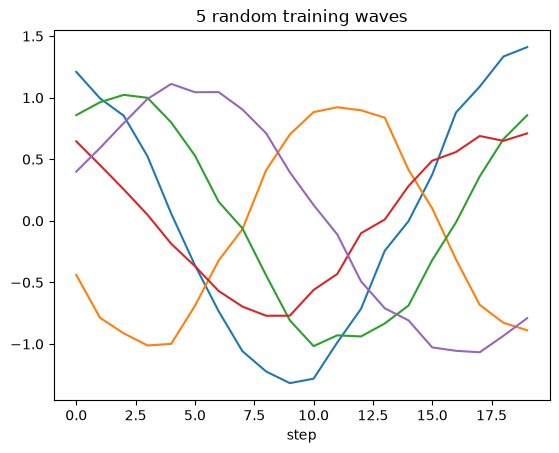

In [3]:
for i in range(5):
    plt.plot(X_train[i].flatten().numpy())
plt.title("5 random training waves")
plt.xlabel("step")
plt.show()

## 2. The model

- `layer` is `nn.RNN` or `nn.LSTM`.
- `num_layers` stacks layers on top of each other: layer 2 reads the outputs of layer 1.
- `nn.Linear` takes the last memory and gives one number: the prediction.

In [4]:
class Model(nn.Module):
    def __init__(self, layer, num_layers):
        super().__init__()
        self.rnn = layer(input_size=1, hidden_size=32, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.rnn(x)          # memory after every step
        return self.fc(out[:, -1])    # use only the last step

## 3. Train and test functions

In [5]:
def train(model, epochs=300):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        loss = loss_fn(model(X_train), y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model

def test_error(model):
    with torch.no_grad():
        return (model(X_test) - y_test).abs().mean().item()   # average error

## 4. Train one LSTM and look at the result

In [6]:
torch.manual_seed(0)
lstm = train(Model(nn.LSTM, num_layers=1))
print("LSTM test error:", round(test_error(lstm), 3))

LSTM test error: 0.062


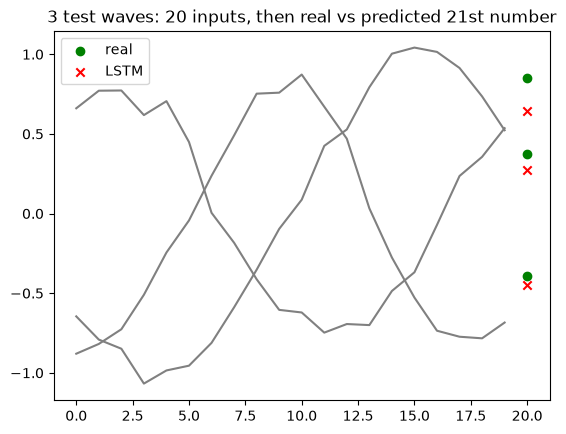

In [7]:
with torch.no_grad():
    pred = lstm(X_test[:3])

for i in range(3):
    plt.plot(range(STEPS), X_test[i].flatten(), color="gray")
    plt.scatter(STEPS, y_test[i], color="green", label="real" if i == 0 else None)
    plt.scatter(STEPS, pred[i], color="red", marker="x", label="LSTM" if i == 0 else None)
plt.title("3 test waves: 20 inputs, then real vs predicted 21st number")
plt.legend()
plt.show()

## 5. Compare RNN and LSTM with 1, 2 and 3 layers

Same data, same training, same seed. We measure:

- error: average distance between prediction and real value (smaller = better)
- weights: how many numbers the model learns
- time: training time in seconds

We also add a simple guess: "next number = last number".

In [8]:
results = []
results.append({"model": "simple guess", "error": (X_test[:, -1] - y_test).abs().mean().item(),
                "weights": 0, "time (s)": 0})

for layer, name in [(nn.RNN, "RNN"), (nn.LSTM, "LSTM")]:
    for num_layers in [1, 2, 3, 4, 5, 6]:
        torch.manual_seed(0)
        model = Model(layer, num_layers)
        start = time.time()
        train(model)
        results.append({"model": f"{name} {num_layers} layer",
                        "error": test_error(model),
                        "weights": sum(p.numel() for p in model.parameters()),
                        "time (s)": time.time() - start})
        print("done:", name, num_layers, "layer")

table = pd.DataFrame(results).set_index("model").round(3)
table

done: RNN 1 layer


done: RNN 2 layer


done: RNN 3 layer


done: LSTM 1 layer


done: LSTM 2 layer


done: LSTM 3 layer


,error,weights,time (s)
model,,,
simple guess,0.194,0,0.000
RNN 1 layer,0.073,1153,3.356
RNN 2 layer,0.062,3265,5.024
RNN 3 layer,0.061,5377,6.658
LSTM 1 layer,0.062,4513,4.455
LSTM 2 layer,0.052,12961,9.298
LSTM 3 layer,0.051,21409,16.630


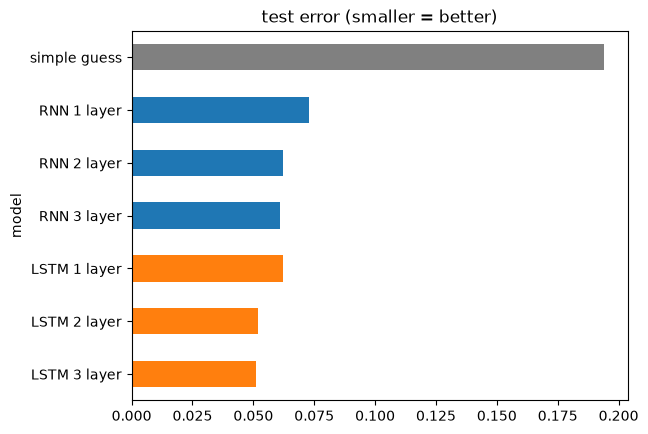

In [9]:
table["error"].plot.barh(color=["gray"] + ["tab:blue"] * 3 + ["tab:orange"] * 3)
plt.gca().invert_yaxis()
plt.title("test error (smaller = better)")
plt.show()

## 6. What is the difference?

**RNN vs LSTM**

- RNN: one simple memory. At every step it rewrites the whole memory, so old steps fade.
- LSTM: adds a second memory (cell state) and 3 gates: forget, input, output.
  The gates decide what to delete, what to write and what to show. Old information survives longer.
- That is why the LSTM has about 4 times more weights than an RNN of the same size.
- In the table: with the same number of layers, LSTM has a smaller error than RNN.

**1 layer vs more layers**

- 2 layers: layer 1 finds simple patterns, layer 2 combines them. The error goes down.
- 3 layers: only a very small extra gain, but more weights and more training time.
- More layers is not always better. Here 2 layers is a good choice.

**The simple guess** is much worse than all models: the models really learned the shape of the waves.

## 7. Try your own numbers

Give 20 numbers and get the predicted next number from the 1-layer LSTM.

In [10]:
numbers = np.sin(0.3 * np.arange(20))      # a clean wave, change it as you like

x = torch.tensor(numbers, dtype=torch.float32).reshape(1, 20, 1)
with torch.no_grad():
    print("predicted next:", round(lstm(x).item(), 3))
print("real next      :", round(np.sin(0.3 * 20), 3))

predicted next: -0.328
real next      : -0.279


## Summary

1. A sequence is data where the order matters.
2. RNN / LSTM read it step by step and keep a memory.
3. LSTM has gates, so it remembers better than a plain RNN, but it has more weights.
4. `num_layers` stacks layers. A second layer helps; more layers give little extra and cost more time.
5. In code, the only changes are `nn.RNN` / `nn.LSTM` and `num_layers=...`.